In [9]:
import os
import json
import numpy as np
import tensorflow as tf
from PIL import Image
import imagehash
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
DATASET_DIR = r"D:\Ai Models\MangoLeafDataset"   
IMG_SIZE = (260, 260)          
BATCH_SIZE = 32
SEED = 123
OUT_DIR = "mango_leaf_model_v3_advanced"
os.makedirs(OUT_DIR, exist_ok=True)

STAGE1_EPOCHS = 25   
STAGE2_EPOCHS = 15   
STAGE3_EPOCHS = 10   
MIXUP_ALPHA = 0.2

In [11]:
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
NUM_CLASSES = len(class_names)
print(f"Classes found ({NUM_CLASSES}): {class_names}")

filepaths, labels = [], []
for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            filepaths.append(os.path.join(cls_dir, fname))
            labels.append(idx)

print(f"Total images before dedup: {len(filepaths)}")

Classes found (8): ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Total images before dedup: 4000


In [12]:
print("Scanning for near-duplicate images...")
hash_to_path = defaultdict(list)
for fp in filepaths:
    try:
        h = imagehash.phash(Image.open(fp))
        hash_to_path[str(h)].append(fp)
    except Exception as e:
        print(f"  Skipping unreadable file {fp}: {e}")

duplicates_removed = sum(len(p) - 1 for p in hash_to_path.values())
keep_set = {paths[0] for paths in hash_to_path.values()}
print(f"Duplicate images removed: {duplicates_removed}")

filtered = [(fp, lb) for fp, lb in zip(filepaths, labels) if fp in keep_set]
filepaths, labels = zip(*filtered)
filepaths, labels = list(filepaths), list(labels)
print(f"Total images after dedup: {len(filepaths)}")


Scanning for near-duplicate images...
Duplicate images removed: 268
Total images after dedup: 3732


In [ ]:
train_fp, temp_fp, train_lb, temp_lb = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_fp, test_fp, val_lb, test_lb = train_test_split(
    temp_fp, temp_lb, test_size=0.50, stratify=temp_lb, random_state=SEED
)
print(f"Train: {len(train_fp)}  Val: {len(val_fp)}  Test: {len(test_fp)}")


def make_dataset(filepaths, labels, training=False, one_hot=False, mixup=False):
    path_ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        if one_hot:
            label = tf.one_hot(label, depth=NUM_CLASSES)
        return img, label

    ds = path_ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)

    if mixup:
        ds = ds.map(lambda x, y: apply_mixup(x, y, MIXUP_ALPHA),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds


def _sample_beta(shape, alpha):
    # Beta(alpha, alpha) via two Gamma(alpha, 1) draws - avoids deprecated APIs
    gamma1 = tf.random.gamma(shape, alpha)
    gamma2 = tf.random.gamma(shape, alpha)
    return gamma1 / (gamma1 + gamma2)


def apply_mixup(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    lam = _sample_beta([batch_size], alpha)
    lam_x = tf.reshape(lam, (-1, 1, 1, 1))
    lam_y = tf.reshape(lam, (-1, 1))

    idx = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)

    mixed_images = lam_x * images + (1.0 - lam_x) * tf.cast(images2, images.dtype)
    mixed_labels = lam_y * tf.cast(labels, tf.float32) + (1.0 - lam_y) * tf.cast(labels2, tf.float32)
    return mixed_images, mixed_labels


train_dataset_mixup = make_dataset(train_fp, train_lb, training=True, one_hot=True, mixup=True)

train_dataset_plain = make_dataset(train_fp, train_lb, training=True, one_hot=False, mixup=False)


val_dataset_onehot = make_dataset(val_fp, val_lb, training=False, one_hot=True)
val_dataset = make_dataset(val_fp, val_lb, training=False, one_hot=False)
test_dataset = make_dataset(test_fp, test_lb, training=False, one_hot=False)


Train: 2612  Val: 560  Test: 560


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_lb), y=train_lb
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights (Stage 3 only):", class_weight_dict)


data_augmentation = tf.keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name="augmentation")

Class weights (Stage 3 only): {0: np.float64(0.9602941176470589), 1: np.float64(0.9382183908045977), 2: np.float64(1.793956043956044), 3: np.float64(0.9491279069767442), 4: np.float64(0.9382183908045977), 5: np.float64(0.9328571428571428), 6: np.float64(0.9328571428571428), 7: np.float64(0.9328571428571428)}


In [15]:
base_model = EfficientNetB2(
    include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # Stage 1: fully frozen

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

def compile_model(lr, loss):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=loss,
        metrics=["accuracy"],
    )

categorical_loss = tf.keras.losses.CategoricalCrossentropy()   # for mixup (soft labels)
sparse_loss = tf.keras.losses.SparseCategoricalCrossentropy()  # for plain-label Stage 3

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,168,833 (31.16 MB)

 Trainable params: 397,448 (1.52 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [ ]:
compile_model(1e-3, categorical_loss)

stage1_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage1_best.keras"),
                     monitor="val_accuracy", save_best_only=True),
]

print("\n=== STAGE 1: training head, backbone frozen, Mixup ===")
history1 = model.fit(train_dataset_mixup, validation_data=val_dataset_onehot,
                      epochs=STAGE1_EPOCHS, callbacks=stage1_cb)

print(history1.history.keys())
print("Final Training Accuracy :", history1.history["accuracy"][-1])
print("Final Validation Accuracy :", history1.history["val_accuracy"][-1])
print("Final Training Loss :", history1.history["loss"][-1])
print("Final Validation :", history1.history["val_loss"][-1])


base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

compile_model(1e-4, categorical_loss)

stage2_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage2_best.keras"),
                     monitor="val_accuracy", save_best_only=True),
]

print("\n=== STAGE 2: fine-tuning last 30 layers, Mixup ===")
history2 = model.fit(train_dataset_mixup, validation_data=val_dataset_onehot,
                      epochs=STAGE2_EPOCHS, callbacks=stage2_cb)

print(history2.history.keys())
print("Final Training Accuracy :", history2.history["accuracy"][-1])
print("Final Validation Accuracy :", history2.history["val_accuracy"][-1])
print("Final Training Loss :", history2.history["loss"][-1])
print("Final Validation :", history2.history["val_loss"][-1])


=== STAGE 1: training head, backbone frozen, Mixup ===
Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6930 - loss: 1.2187 - val_accuracy: 0.9571 - val_loss: 0.6186 - learning_rate: 0.0010
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8361 - loss: 0.7931 - val_accuracy: 0.9786 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8622 - loss: 0.7143 - val_accuracy: 0.9804 - val_loss: 0.2336 - learning_rate: 0.0010
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8871 - loss: 0.6658 - val_accuracy: 0.9875 - val_loss: 0.1685 - learning_rate: 0.0010
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8924 - loss: 0.6344 - val_accuracy: 0.9857 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8978 - loss: 0.6183 - val_accuracy: 0.9875 - val_loss: 0.1205 - learning_rate: 0.0010
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
for layer in base_model.layers[:-60]:
    layer.trainable = False
for layer in base_model.layers[-60:]:
    layer.trainable = True

compile_model(2e-5, sparse_loss)

stage3_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage3_best.keras"),
                     monitor="val_accuracy", save_best_only=True),
]

print("\n=== STAGE 3: fine-tuning last 60 layers, plain labels, class weights ===")
history3 = model.fit(train_dataset_plain, validation_data=val_dataset,
                      epochs=STAGE3_EPOCHS, class_weight=class_weight_dict,
                      callbacks=stage3_cb)

print(history3.history.keys())
print("Final Training Accuracy :", history3.history["accuracy"][-1])
print("Final Validation Accuracy :", history3.history["val_accuracy"][-1])
print("Final Training Loss :", history3.history["loss"][-1])
print("Final Validation :", history3.history["val_loss"][-1])


=== STAGE 3: fine-tuning last 60 layers, plain labels, class weights ===
Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9839 - loss: 0.1618 - val_accuracy: 1.0000 - val_loss: 0.0788
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9839 - loss: 0.1299 - val_accuracy: 1.0000 - val_loss: 0.0771
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9923 - loss: 0.1093 - val_accuracy: 1.0000 - val_loss: 0.0765
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9885 - loss: 0.1092 - val_accuracy: 0.9982 - val_loss: 0.0754
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9935 - loss: 0.0986 - val_accuracy: 1.0000 - val_loss: 0.0736
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9950 - loss: 0.0939 - val_accuracy: 1.0000 - val_loss: 0.0726
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9954 - loss: 0.0910 - val_accuracy: 1.0000 - val_loss: 0.0720
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━

In [18]:
def summarize_history(name, history):
    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = history.history["val_accuracy"].index(best_val_acc) + 1
    summary = {
        "epochs": len(history.history["val_accuracy"]),
        "best_val_accuracy": best_val_acc,
        "best_val_accuracy_epoch": best_val_acc_epoch,
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_train_loss": history.history["loss"][-1],
    }
    print(f"\n--- {name} ---")
    for k, v in summary.items():
        print(f"  {k}: {v}")
    return summary

print("\n" + "=" * 55)
print("VALIDATION METRICS SUMMARY (per training stage)")
print("=" * 55)
stage1_summary = summarize_history("Stage 1 (frozen backbone, Mixup)", history1)
stage2_summary = summarize_history("Stage 2 (fine-tune last 30, Mixup)", history2)
stage3_summary = summarize_history("Stage 3 (fine-tune last 60, plain + class weights)", history3)

with open(os.path.join(OUT_DIR, "validation_metrics_summary.json"), "w") as f:
    json.dump({"stage1": stage1_summary, "stage2": stage2_summary, "stage3": stage3_summary}, f, indent=2)



VALIDATION METRICS SUMMARY (per training stage)

--- Stage 1 (frozen backbone, Mixup) ---
  epochs: 25
  best_val_accuracy: 1.0
  best_val_accuracy_epoch: 13
  final_val_accuracy: 1.0
  final_val_loss: 0.08659252524375916
  final_train_accuracy: 0.9437212944030762
  final_train_loss: 0.47718286514282227

--- Stage 2 (fine-tune last 30, Mixup) ---
  epochs: 7
  best_val_accuracy: 1.0
  best_val_accuracy_epoch: 2
  final_val_accuracy: 1.0
  final_val_loss: 0.08272954076528549
  final_train_accuracy: 0.9486983418464661
  final_train_loss: 0.45830944180488586

--- Stage 3 (fine-tune last 60, plain + class weights) ---
  epochs: 10
  best_val_accuracy: 1.0
  best_val_accuracy_epoch: 1
  final_val_accuracy: 1.0
  final_val_loss: 0.07057329267263412
  final_train_accuracy: 0.9969372153282166
  final_train_loss: 0.08152279257774353


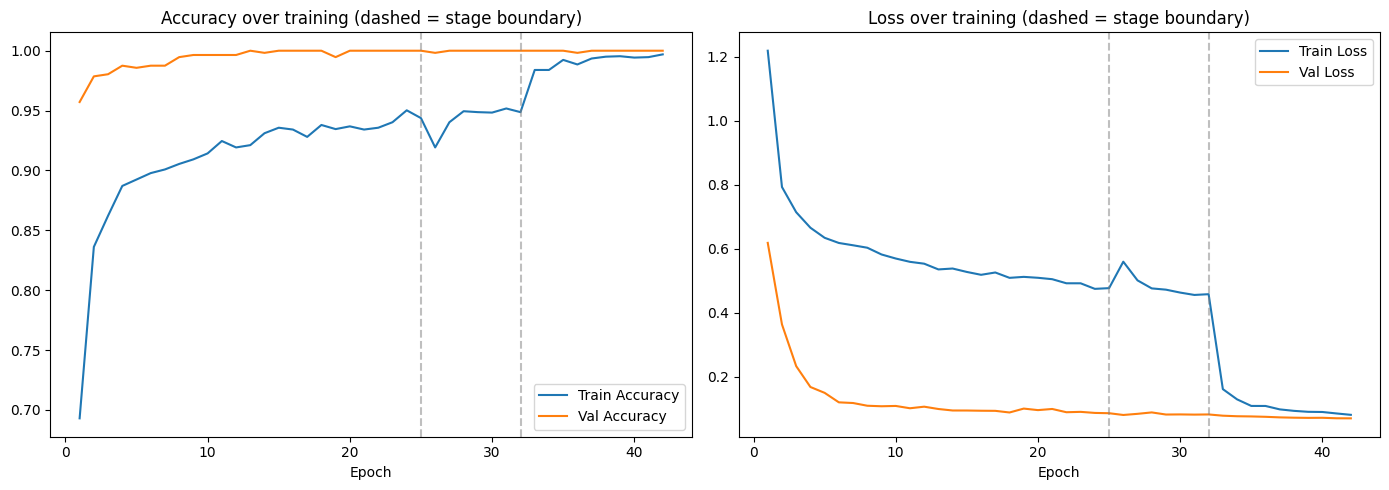

In [19]:
def stitch(key):
    return history1.history[key] + history2.history[key] + history3.history[key]

train_acc_all = stitch("accuracy")
val_acc_all = stitch("val_accuracy")
train_loss_all = stitch("loss")
val_loss_all = stitch("val_loss")
epochs_range = range(1, len(train_acc_all) + 1)
stage1_end = len(history1.history["accuracy"])
stage2_end = stage1_end + len(history2.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, train_acc_all, label="Train Accuracy")
axes[0].plot(epochs_range, val_acc_all, label="Val Accuracy")
axes[0].axvline(stage1_end, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(stage2_end, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Accuracy over training (dashed = stage boundary)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, train_loss_all, label="Train Loss")
axes[1].plot(epochs_range, val_loss_all, label="Val Loss")
axes[1].axvline(stage1_end, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(stage2_end, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Loss over training (dashed = stage boundary)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"))
plt.show()

In [ ]:

test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nPlain test accuracy: {test_acc:.4f}")


print("\nRunning Test-Time Augmentation for final predictions...")
tta_augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

def tta_predict(dataset, n_aug=5):
    all_probs = []
    for images, _ in dataset:
        base_probs = model.predict(images, verbose=0)
        aug_probs_sum = base_probs.copy()
        for _ in range(n_aug):
            aug_images = tta_augmenter(images, training=True)
            aug_probs_sum += model.predict(aug_images, verbose=0)
        all_probs.append(aug_probs_sum / (n_aug + 1))
    return np.concatenate(all_probs, axis=0)

y_true = np.array(test_lb)
y_pred_probs_tta = tta_predict(test_dataset, n_aug=5)
y_pred_tta = np.argmax(y_pred_probs_tta, axis=1)
tta_acc = np.mean(y_pred_tta == y_true)
print(f"TTA test accuracy: {tta_acc:.4f}  (plain was {test_acc:.4f})")

18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9982 - loss: 0.0711

Plain test accuracy: 0.9982

Running Test-Time Augmentation for final predictions...
TTA test accuracy: 1.0000  (plain was 0.9982)


In [ ]:
print("\nClassification Report (TTA):")
print(classification_report(y_true, y_pred_tta, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_tta)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Greens", colorbar=True)
plt.title("Mango Leaf Disease - Confusion Matrix (v3, TTA)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_tta.png"))
plt.show()


Classification Report (TTA):
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        73
Bacterial Canker       1.00      1.00      1.00        75
  Cutting Weevil       1.00      1.00      1.00        39
        Die Back       1.00      1.00      1.00        74
      Gall Midge       1.00      1.00      1.00        74
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       1.00      1.00      1.00        75
     Sooty Mould       1.00      1.00      1.00        75

        accuracy                           1.00       560
       macro avg       1.00      1.00      1.00       560
    weighted avg       1.00      1.00      1.00       560



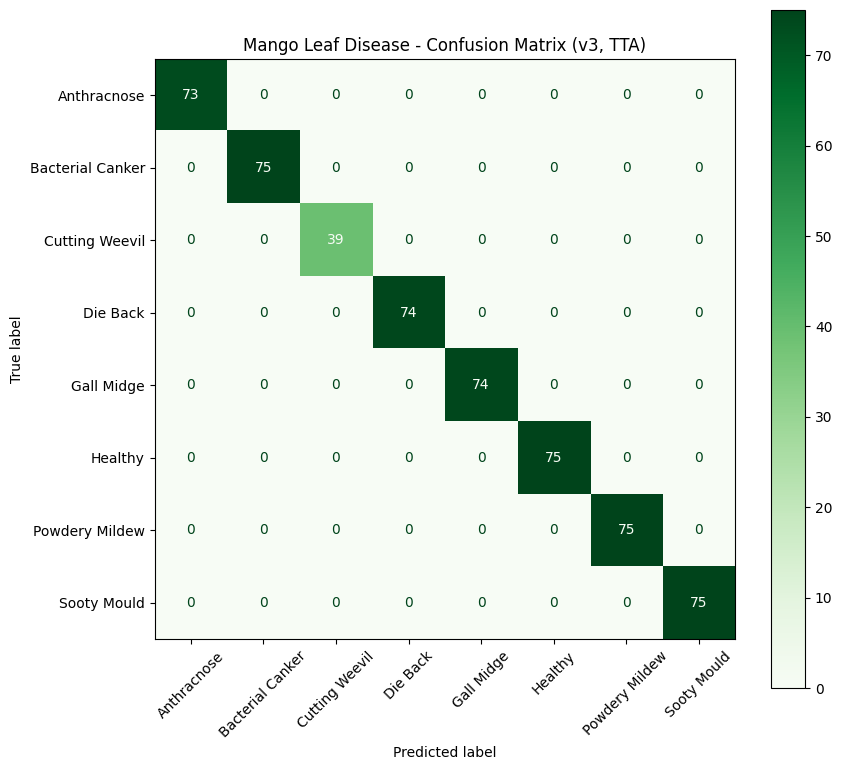

INFO:tensorflow:Assets written to: C:\Users\udnrm\AppData\Local\Temp\tmpyvk3xtwh\assets


INFO:tensorflow:Assets written to: C:\Users\udnrm\AppData\Local\Temp\tmpyvk3xtwh\assets


Saved artifact at 'C:\Users\udnrm\AppData\Local\Temp\tmpyvk3xtwh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name='keras_tensor_702')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  3031687822224: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  3031687820880: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  3026784520528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683049872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683047952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683050448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683050256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683040848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683050640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3031683050064: TensorSpec(shape=(), dtype=tf.resour

In [ ]:
model.save(os.path.join(OUT_DIR, "mango_leaf_model_v3_final.keras"))

with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(os.path.join(OUT_DIR, "mango_leaf_model_v3.tflite"), "wb") as f:
    f.write(tflite_model)

print(f"\nDone. Artifacts saved to: {OUT_DIR}/")
print("  - mango_leaf_model_v3_final.keras  (deploy this)")
print("  - class_names.json")
print("  - mango_leaf_model_v3.tflite")
print("  - training_curves.png")
print("  - confusion_matrix_tta.png")
print("  - validation_metrics_summary.json")
print(f"\nFINAL RESULTS -> plain acc: {test_acc:.4f} | TTA acc: {tta_acc:.4f}")
